# DAT410 - Design of AI Systems

## Group 69, Module 5: Semantic Segmentation with Deep Learning

Name: Chung Fung Oi | Jana Leong

Course: Bachelor of Computer Science 

Email: fungo@student.chalmers.se | janal@student.chalmers.se

Number of hours spent: 13

### Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rasterio
from sklearn.model_selection import KFold
from glob import glob
import tensorflow as tf

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Hyperparameters & Config

In [2]:
IMG_SIZE = 224          # Resize all tiles to 224x224
NUM_CLASSES = 6
BATCH_SIZE = 16
EPOCHS = 20
NUM_FOLDS = 5
NUM_SAMPLES = 5000      # Randomly sample 5000 images
TRAIN_FOLDS = [0, 1, 2] # Folds 1-3 for training
VAL_FOLD = 3            # Fold 4 for validation
TEST_FOLD = 4           # Fold 5 for test

# Class definitions
CLASS_NAMES = [
    "Impervious surface",
    "Building",
    "Tree",
    "Low vegetation",
    "Car",
    "Clutter/Background"
]

CLASS_COLORS = [
    "#8B0000",  # Dark red  - Impervious surface
    "#FFFF00",  # Yellow    - Building
    "#006400",  # Dark green- Tree
    "#90EE90",  # Light green- Low vegetation
    "#FFA500",  # Orange    - Car
    "#808080",  # Gray      - Clutter/Background
]

### Dataset Preparation

#### Step 1

We split the dataset into five folds for cross-validation using a reproducible random sampling procedure. First, we fixed the random seed (seed = 42) and applied it consistently to Python’s random, NumPy (np.random), and TensorFlow (tf.random) so that the same files are selected and split each time the notebook is run.

From the full list of GeoTIFF files (extracted_files), we then randomly sampled sample_no = 5000 images using random.sample, which selects files without replacement. After sampling, we shuffled the selected filenames to remove any bias from the original file ordering.

Next, we partitioned the shuffled list into five approximately equal-sized folds using np.array_split(sampled_files, 5). This produces five non-overlapping subsets (Fold 1 to Fold 5), each containing roughly 1,000 images. We printed each fold’s size to verify the split.

Finally, for transparency and reproducibility, we saved the membership of each fold to disk as text files (fold_1_files.txt … fold_5_files.txt) under ./tfrecord_folds. Each file contains the basenames of the GeoTIFF images assigned to that fold. These fold definitions are then used in later steps of the assignment.

In [20]:
def load_geotiff(filepath):
    """Load a GeoTIFF file and return numpy array (H, W, 6)."""
    with rasterio.open(filepath) as src:
        data = src.read()  # shape: (6, H, W)
    return np.transpose(data, (1, 2, 0)).astype(np.float32)  # (H, W, 6)

In [4]:
def preprocess_image(data, img_size=IMG_SIZE):
    """
    Resize, normalize inputs, and one-hot encode labels.
    Returns: features (H, W, 5), labels (H, W, NUM_CLASSES)
    Assumptions:
      - Bands 0-4 are input features (R, G, B, IR, Elevation)
      - Band 5 (index 5) contains pixel-wise class labels (0-5)
      - Input bands are normalized to [0, 1] by dividing by 65535
        (16-bit data) or 255 (8-bit); we use max normalization.
    """
    features = data[:, :, :5]
    labels = data[:, :, 5].astype(np.int32)

    # Resize
    features = tf.image.resize(features, [img_size, img_size]).numpy()
    labels = tf.image.resize(
        labels[:, :, np.newaxis], [img_size, img_size],
        method='nearest'
    ).numpy()[:, :, 0].astype(np.int32)

    # Normalize features to [0, 1]
    for c in range(5):
        ch = features[:, :, c]
        ch_max = ch.max()
        if ch_max > 0:
            features[:, :, c] = ch / ch_max

    # One-hot encode labels
    labels_oh = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    return features.astype(np.float32), labels_oh.astype(np.float32)

In [5]:
def prepare_dataset(data_dir, num_samples=NUM_SAMPLES):
    """
    Read all .tif files, randomly sample num_samples, split into 5 folds,
    and save fold indices.
    Returns list of 5 fold file-path lists.
    """
    all_files = glob(os.path.join(data_dir, "*.tif"))
    print(f"Total GeoTIFF files found: {len(all_files)}")

    # Random sample
    sampled_files = random.sample(all_files, NUM_SAMPLES)
    random.shuffle(sampled_files)

    folds = np.array_split(sampled_files, NUM_FOLDS)
    folds = [list(f) for f in folds]
    for i, f in enumerate(folds, 1):
        print(f"Fold {i} size: {len(f)}")

    return folds

In [6]:
def _bytes_feature(value: bytes):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value: int):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[int(value)]))

In [7]:
def create_tfrecord(file_list, output_path, data_dir):
    """
    file_list: list of full paths to .tif files
    output_path: path to output .tfrecord
    """
    count = 0
    missing = 0

    with tf.io.TFRecordWriter(output_path) as writer:
      for item in file_list:
          file_path = item if os.path.isabs(item) or item.startswith("./") or "/" in item else os.path.join(data_dir, item)

          if not os.path.exists(file_path):
              missing += 1
              raise FileNotFoundError(f"GeoTIFF not found: {file_path}")

          with rasterio.open(file_path) as src:
              bands = src.read()
              if bands.shape[0] < 6:
                  raise ValueError(f"{file_path} has {bands.shape[0]} bands; expected 6.")

              inputs = bands[:5]
              target = bands[5].astype(np.uint8)

          h, w = inputs.shape[1], inputs.shape[2]
          c = inputs.shape[0]

          feature = {
              "inputs": _bytes_feature(inputs.tobytes()),
              "target": _bytes_feature(target.tobytes()),
              "height": _int64_feature(h),
              "width": _int64_feature(w),
              "in_channels": _int64_feature(c),
              "filename": _bytes_feature(os.path.basename(file_path).encode("utf-8")),
          }

          example = tf.train.Example(features=tf.train.Features(feature=feature))
          writer.write(example.SerializeToString())
          count += 1

    print(f"Wrote {count} examples -> {output_path}")

In [8]:
def visualize_sample(filepath, save_path=None):
    """
    Visualize a sample GeoTIFF with RGB image, elevation band,
    and target label band.
    """
    with rasterio.open(filepath) as src:
        data = src.read()  # (6, H, W)

    rgb = np.stack([data[0], data[1], data[2]], axis=-1)
    # Normalize for display
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    elevation = data[4]
    labels = data[5].astype(np.int32)

    # Build label color image
    label_img = np.zeros((*labels.shape, 3))
    hex_colors = CLASS_COLORS
    for cls_idx, hex_col in enumerate(hex_colors):
        r = int(hex_col[1:3], 16) / 255
        g = int(hex_col[3:5], 16) / 255
        b = int(hex_col[5:7], 16) / 255
        mask = labels == cls_idx
        label_img[mask] = [r, g, b]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB Image")
    axes[0].axis("off")

    im1 = axes[1].imshow(elevation, cmap="terrain")
    axes[1].set_title("Elevation Band")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Elevation")

    axes[2].imshow(label_img)
    axes[2].set_title("Target Label Band")
    axes[2].axis("off")

    # Legend patches
    patches = [
        mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
        for i in range(NUM_CLASSES)
    ]
    axes[2].legend(handles=patches, loc="lower right", fontsize=8,
                   title="Classes", framealpha=0.8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

### TF dataset pipeline

In [9]:
def tf_dataset_from_files(file_list, bands="rgb_ir", augment=False,
                           batch_size=BATCH_SIZE, shuffle=True):
    """
    Create a tf.data.Dataset from a list of GeoTIFF file paths.
    bands: "rgb_ir" (4 channels) or "all" (5 channels)
    """
    band_indices = [0, 1, 2, 3] if bands == "rgb_ir" else [0, 1, 2, 3, 4]
    n_bands = len(band_indices)

    def load_and_preprocess(path):
        def _load(p):
            p = p.numpy().decode("utf-8")
            data = load_geotiff(p)
            features, label_oh = preprocess_image(data)
            features_sel = features[:, :, band_indices]
            return features_sel.astype(np.float32), label_oh.astype(np.float32)

        features, label = tf.py_function(
            _load, [path], [tf.float32, tf.float32]
        )
        features.set_shape([IMG_SIZE, IMG_SIZE, n_bands])
        label.set_shape([IMG_SIZE, IMG_SIZE, NUM_CLASSES])
        return features, label

    def augment_fn(x, y):
        # Random horizontal flip
        if tf.random.uniform(()) > 0.5:
            x = tf.image.flip_left_right(x)
            y = tf.image.flip_left_right(y)
        # Random vertical flip
        if tf.random.uniform(()) > 0.5:
            x = tf.image.flip_up_down(x)
            y = tf.image.flip_up_down(y)
        # Random 90-degree rotation
        k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
        x = tf.image.rot90(x, k)
        y = tf.image.rot90(y, k)
        return x, y

    ds = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


### CNN model

#### Step 2: Model Architecture

The Simple CNN is a fully convolutional network consisting of two convolutional layers. The input accepts four-channel images (RGB + Infrared) of size 224×224. The first layer applies 32 filters with a 3×3 kernel and ReLU activation, learning low-level spatial features such as edges, color contrasts, and textures. The output layer then applies 6 filters with a 3×3 kernel and softmax activation, producing a per-pixel probability distribution across the six semantic classes. Both layers use same padding to preserve the 224×224 spatial resolution throughout. The model contains only 2,918 trainable parameters, making it extremely lightweight.

In [10]:
def build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 4)):
    """
    Simple 2-layer fully convolutional network.
    Input: (224, 224, 4) -> RGB + IR
    Output: (224, 224, 6) softmax probabilities
    """
    inputs = keras.Input(shape=input_shape, name="input")
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                      name="conv1")(inputs)
    outputs = layers.Conv2D(NUM_CLASSES, (3, 3), activation="softmax",
                            padding="same", name="output")(x)
    model = keras.Model(inputs, outputs, name="SimpleCNN")
    return model

### Encoder Decoder (U-net style)

#### Step 3: Model Architecture

The Encoder-Decoder is a U-Net style fully convolutional network that takes all five input bands (RGB, Infrared, and Elevation) at 224×224 resolution and outputs a per-pixel segmentation map across six classes. It contains 160,166 trainable parameters — roughly 55 times more capacity than the Simple CNN — reflecting its significantly deeper and more expressive architecture. The encoder progressively compresses spatial information while extracting increasingly abstract features. The first convolutional layer (1,472 params) produces 32 feature maps at full 224×224 resolution, capturing low-level edges and textures. A MaxPooling layer then halves the resolution to 112×112, after which a second convolution (18,496 params) produces 64 feature maps capturing more complex patterns. A second MaxPooling reduces resolution further to 56×56, feeding into the bottleneck convolution (36,928 params) which learns the most abstract, high-level representations of the scene at the coarsest resolution. The decoder progressively restores spatial resolution through three transposed convolution layers. Crucially, skip connections via Concatenate layers reintroduce fine-grained spatial detail from the encoder at each resolution level — 112×112 features are concatenated to produce 128 channels, and 224×224 features are concatenated to produce 64 channels. This allows the decoder to combine high-level semantic understanding from the bottleneck with precise boundary information from early encoder layers, which is essential for accurate pixel-wise prediction. The final Conv2D output layer (1,734 params) produces the 6-class softmax probability map at the original 224×224 resolution. The MaxPooling layers and Concatenate operations carry no learnable parameters, which is why their param count shows 0.

In [21]:
def build_encoder_decoder(input_shape=(IMG_SIZE, IMG_SIZE, 5)):
    """
    U-Net style encoder-decoder with skip connections.
    Input: (224, 224, 5) -> RGB + IR + Elevation
    Output: (224, 224, 6) softmax probabilities
    Architecture matches the provided diagram.
    """
    inputs = keras.Input(shape=input_shape, name="input")

    # Encoder
    # Block 1
    c1 = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)   # 112x112x32

    # Block 2
    c2 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)   # 56x56x64

    # Bottleneck
    c3 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(p2)  # 56x56x64

    # Decoder
    # Up 1: 56->112
    u1 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), activation="relu",
                                 padding="same")(c3)   # 112x112x64
    u1 = layers.Concatenate()([u1, c2])                # 112x112x128
    u1 = layers.Conv2DTranspose(32, (3, 3), strides=(1, 1), activation="relu",
                                 padding="same")(u1)   # 112x112x32

    # Up 2: 112->224
    u2 = layers.Conv2DTranspose(32, (3, 3), strides=(2, 2), activation="relu",
                                 padding="same")(u1)   # 224x224x32
    u2 = layers.Concatenate()([u2, c1])                # 224x224x64
    u2 = layers.Conv2DTranspose(32, (3, 3), strides=(1, 1), activation="relu",
                                 padding="same")(u2)   # 224x224x32

    # Output
    outputs = layers.Conv2D(NUM_CLASSES, (3, 3), activation="softmax",
                            padding="same", name="output")(u2)  # 224x224x6

    model = keras.Model(inputs, outputs, name="EncoderDecoder")
    return model


### Training Utilites

In [12]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [13]:
def train_model(model, train_ds, val_ds, model_save_path, epochs=EPOCHS):
    """Train model with ModelCheckpoint to save best val_accuracy model."""
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            verbose=1
        )
    ]
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks
    )
    return history


In [14]:
def plot_training_history(history, title="Training History", save_path=None):
    """Plot training and validation loss and accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Categorical Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Pixel Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [15]:
def evaluate_on_test(model, test_ds):
    """Evaluate model on test fold."""
    results = model.evaluate(test_ds, verbose=1)
    print(f"Test Loss: {results[0]:.4f}")
    print(f"Test Accuracy: {results[1]:.4f}")
    return results


In [16]:
def visualize_prediction(model, filepath, save_path=None):
    """
    Visualize RGB, elevation, ground truth labels, and model predictions
    for a single image (used for Step 3 Encoder-Decoder).
    """
    data = load_geotiff(filepath)
    features, label_oh = preprocess_image(data)

    # All 5 bands for encoder-decoder
    input_tensor = features[np.newaxis, :, :, :]  # (1, 224, 224, 5)
    pred = model.predict(input_tensor)[0]          # (224, 224, 6)
    pred_class = np.argmax(pred, axis=-1)
    true_class = np.argmax(label_oh, axis=-1)

    def class_to_rgb(class_map):
        img = np.zeros((*class_map.shape, 3))
        for cls_idx, hex_col in enumerate(CLASS_COLORS):
            r = int(hex_col[1:3], 16) / 255
            g = int(hex_col[3:5], 16) / 255
            b = int(hex_col[5:7], 16) / 255
            img[class_map == cls_idx] = [r, g, b]
        return img

    rgb = features[:, :, :3]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    elevation = features[:, :, 4]

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB Image")
    axes[0].axis("off")

    im1 = axes[1].imshow(elevation, cmap="terrain")
    axes[1].set_title("Elevation Band")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Elevation")

    axes[2].imshow(class_to_rgb(true_class))
    axes[2].set_title("Ground Truth Labels")
    axes[2].axis("off")

    axes[3].imshow(class_to_rgb(pred_class))
    axes[3].set_title("Predicted Segmentation Map")
    axes[3].axis("off")

    # Legend
    patches = [
        mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
        for i in range(NUM_CLASSES)
    ]
    axes[3].legend(handles=patches, loc="lower right", fontsize=7,
                   title="Classes", framealpha=0.8)

    plt.suptitle("Encoder-Decoder Prediction", fontsize=14, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

### Main Code Pipeline

In [17]:
def main(data_dir):
    """
    Full pipeline:
      1. Dataset preparation & visualization
      2. Simple CNN training/evaluation
      3. Encoder-Decoder training/evaluation
    
    Assumptions:
    - data_dir contains all .tif files
    - Each .tif has 6 bands: R, G, B, IR, Elevation, Labels
    - Labels are integer-coded 0-5
    - Images are resized to 224x224
    - 5000 images randomly sampled
    - Folds 1-3 (indices 0,1,2) for training, Fold 4 (idx 3) for val,
      Fold 5 (idx 4) for test
    - Learning rate: 1e-3, Optimizer: Adam
    - Batch size: 16, Epochs: 20
    - Best model saved by highest val_accuracy
    - Data augmentation: random horizontal flip, vertical flip, 90-degree rotation
    """

    os.makedirs("outputs", exist_ok=True)

    # ----- STEP 1: Dataset Preparation -----
    print("\n=== STEP 1: Dataset Preparation ===")
    folds = prepare_dataset(data_dir, num_samples=NUM_SAMPLES)

    # save fold records 
    tfrecord_paths = []
    for i in range(5):
        out_path = os.path.join(data_dir, f"fold_{i+1}.tfrecord")
        tfrecord_paths.append(out_path)
        create_tfrecord(folds[i], out_path, data_dir)

    print("TFRecords written:")
    for p in tfrecord_paths:
        print(" -", p)

    # Visualize a sample image (pick first file from fold 0 that isn't the example)
    sample_file = folds[0][0]
    print(f"\nVisualizing sample: {os.path.basename(sample_file)}")
    visualize_sample(sample_file, save_path="outputs/step1_sample_visualization.png")

    print("\nDataset split into 5 folds for cross-validation:")
    print("  - Training:   Folds 1, 2, 3")
    print("  - Validation: Fold 4")
    print("  - Test:       Fold 5")
    print("  Each fold contains ~1000 images (of 5000 total)")

    # Collect file lists
    train_files = folds[TRAIN_FOLDS[0]] + folds[TRAIN_FOLDS[1]] + folds[TRAIN_FOLDS[2]]
    val_files = folds[VAL_FOLD]
    test_files = folds[TEST_FOLD]
    print(f"\nTrain: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

    # ----- STEP 2: Simple CNN -----
    print("\n=== STEP 2: Simple CNN (RGB + IR) ===")

    train_ds_simple = tf_dataset_from_files(
        train_files, bands="rgb_ir", augment=True, shuffle=True
    )
    val_ds_simple = tf_dataset_from_files(
        val_files, bands="rgb_ir", augment=False, shuffle=False
    )
    test_ds_simple = tf_dataset_from_files(
        test_files, bands="rgb_ir", augment=False, shuffle=False
    )

    simple_model = build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 4))
    simple_model = compile_model(simple_model)
    simple_model.summary()

    history_simple = train_model(
        simple_model, train_ds_simple, val_ds_simple,
        model_save_path="outputs/simple_cnn_best.keras"
    )

    plot_training_history(
        history_simple, title="Simple CNN",
        save_path="outputs/step2_training_history.png"
    )

    # Load best model and evaluate
    best_simple = keras.models.load_model("outputs/simple_cnn_best.keras")
    print("\nSimple CNN - Test Evaluation:")
    evaluate_on_test(best_simple, test_ds_simple)

    # ----- STEP 3: Encoder-Decoder -----
    print("\n=== STEP 3: Encoder-Decoder (RGB + IR + Elevation) ===")

    train_ds_enc = tf_dataset_from_files(
        train_files, bands="all", augment=True, shuffle=True
    )
    val_ds_enc = tf_dataset_from_files(
        val_files, bands="all", augment=False, shuffle=False
    )
    test_ds_enc = tf_dataset_from_files(
        test_files, bands="all", augment=False, shuffle=False
    )

    enc_dec_model = build_encoder_decoder(input_shape=(IMG_SIZE, IMG_SIZE, 5))
    enc_dec_model = compile_model(enc_dec_model)
    enc_dec_model.summary()

    history_enc = train_model(
        enc_dec_model, train_ds_enc, val_ds_enc,
        model_save_path="outputs/encoder_decoder_best.keras"
    )

    plot_training_history(
        history_enc, title="Encoder-Decoder",
        save_path="outputs/step3_training_history.png"
    )

    # Load best model and evaluate
    best_enc = keras.models.load_model("outputs/encoder_decoder_best.keras")
    print("\nEncoder-Decoder - Test Evaluation:")
    evaluate_on_test(best_enc, test_ds_enc)

    # Visualize prediction on a test sample
    test_sample_file = test_files[0]
    visualize_prediction(
        best_enc, test_sample_file,
        save_path="outputs/step3_prediction_visualization.png"
    )

    print("\nAll outputs saved to ./outputs/")


### Run Code

In [18]:
DATA_DIR = "/Users/eliberp/Downloads/module5group69/Potsdam-GeoTif"


=== STEP 1: Dataset Preparation ===
Total GeoTIFF files found: 15048
Fold 1 size: 1000
Fold 2 size: 1000
Fold 3 size: 1000
Fold 4 size: 1000
Fold 5 size: 1000
Wrote 1000 examples -> /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_1.tfrecord
Wrote 1000 examples -> /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_2.tfrecord
Wrote 1000 examples -> /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_3.tfrecord
Wrote 1000 examples -> /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_4.tfrecord
Wrote 1000 examples -> /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_5.tfrecord
TFRecords written:
 - /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_1.tfrecord
 - /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_2.tfrecord
 - /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_3.tfrecord
 - /Users/eliberp/Downloads/module5group69/Potsdam-GeoTif/fold_4.tfrecord
 - /Users/eliberp/Downloads/module5group69/Potsdam-GeoT

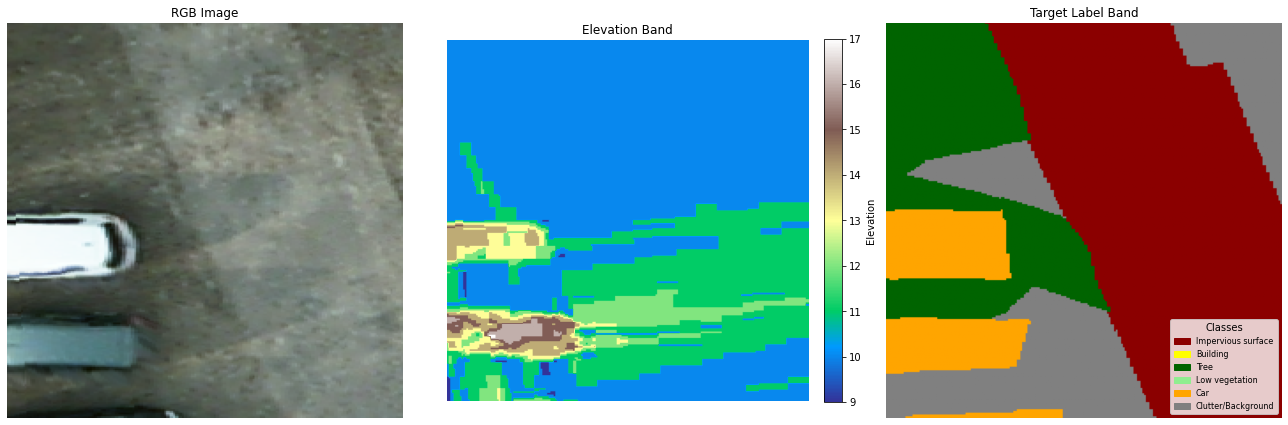


Dataset split into 5 folds for cross-validation:
  - Training:   Folds 1, 2, 3
  - Validation: Fold 4
  - Test:       Fold 5
  Each fold contains ~1000 images (of 5000 total)

Train: 3000, Val: 1000, Test: 1000

=== STEP 2: Simple CNN (RGB + IR) ===


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 224, 224, 6)    │         1,734 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,918 (11.40 KB)

 Trainable params: 2,918 (11.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.3034 - loss: 1.5900
Epoch 1: val_accuracy improved from None to 0.42765, saving model to outputs/simple_cnn_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 59s 308ms/step - accuracy: 0.3624 - loss: 1.5042 - val_accuracy: 0.4277 - val_loss: 1.3873
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.3975 - loss: 1.3805
Epoch 2: val_accuracy improved from 0.42765 to 0.43533, saving model to outputs/simple_cnn_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 304ms/step - accuracy: 0.4161 - loss: 1.3650 - val_accuracy: 0.4353 - val_loss: 1.3355
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.4518 - loss: 1.3338
Epoch 3: val_accuracy improved from 0.43533 to 0.48242, saving model to outputs/simple_cnn_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 301ms/step - accuracy: 0.4595 - loss: 1.3178 - val_accuracy: 0.4824 - val_loss: 1.2931
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.4711 

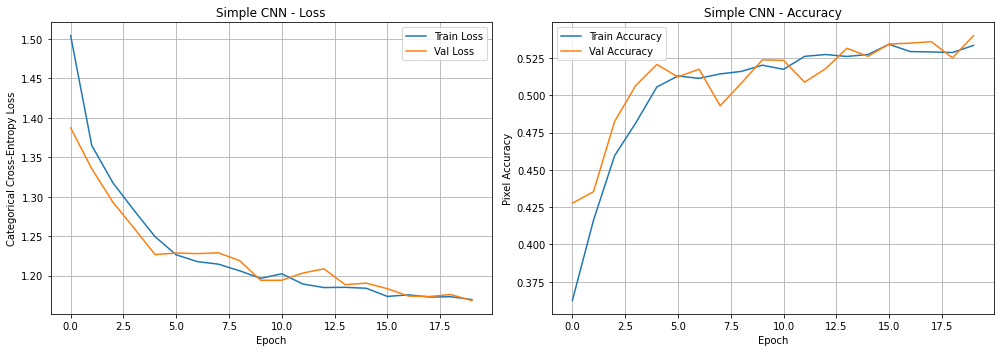


Simple CNN - Test Evaluation:
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.5119 - loss: 1.1831
Test Loss: 1.1831
Test Accuracy: 0.5119

=== STEP 3: Encoder-Decoder (RGB + IR + Elevation) ===


Model: "EncoderDecoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,472 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 112, 112,  │     36,928 │ conv2d_2[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112, 112,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 112, 112,  │     36,896 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 224, 224,  │      9,248 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 224, 224,  │     18,464 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Conv2D)     │ (None, 224, 224,  │      1,734 │ conv2d_transpose… │
│                     │ 6)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 160,166 (625.65 KB)

 Trainable params: 160,166 (625.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4218 - loss: 1.4321
Epoch 1: val_accuracy improved from None to 0.51237, saving model to outputs/encoder_decoder_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.4884 - loss: 1.3142 - val_accuracy: 0.5124 - val_loss: 1.2468
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5403 - loss: 1.1691
Epoch 2: val_accuracy improved from 0.51237 to 0.55925, saving model to outputs/encoder_decoder_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.5473 - loss: 1.1619 - val_accuracy: 0.5593 - val_loss: 1.1492
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5635 - loss: 1.1185
Epoch 3: val_accuracy did not improve from 0.55925
188/188 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.5701 - loss: 1.0951 - val_accuracy: 0.5579 - val_loss: 1.1040
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5636 - loss: 1.1094
Epoch 4: val_accuracy improved from 0.55925 

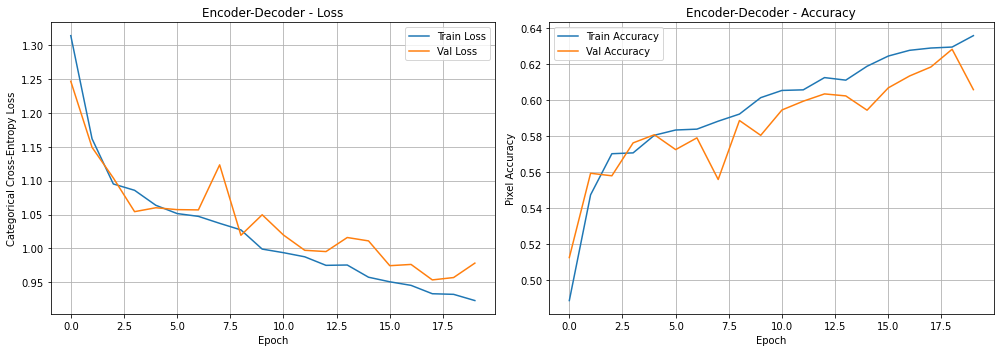


Encoder-Decoder - Test Evaluation:
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 415ms/step - accuracy: 0.6240 - loss: 0.9677
Test Loss: 0.9677
Test Accuracy: 0.6240
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


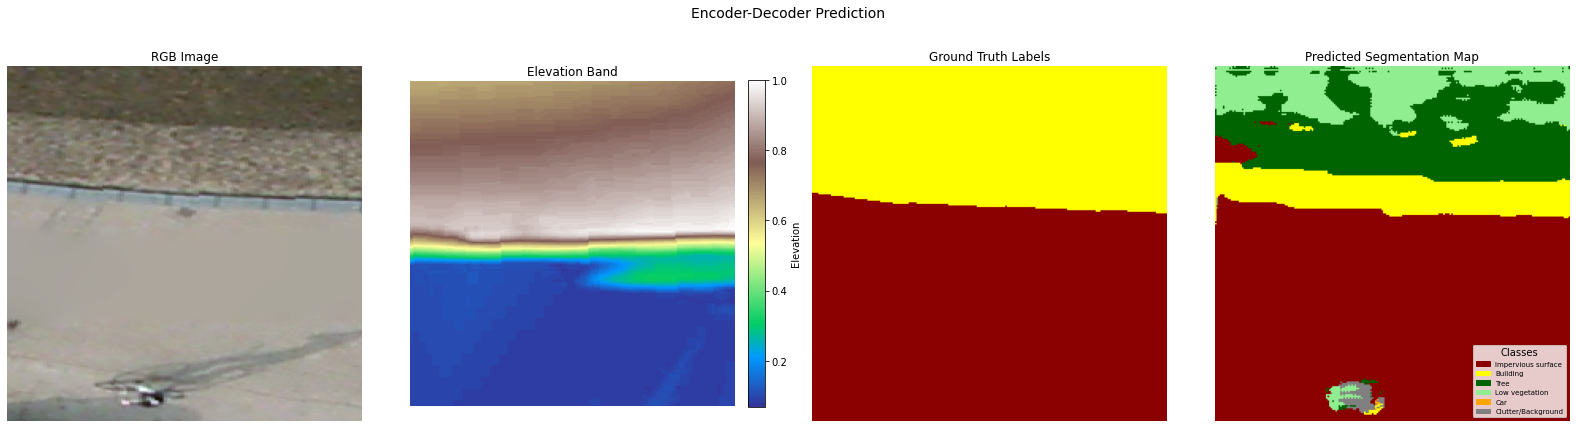


All outputs saved to ./outputs/


In [19]:
main(DATA_DIR)

## Analysis

### CNN Model

#### Training and Validation Loss

The loss curve shows a consistent and stable decrease for both training and validation loss across all 20 epochs. Training loss begins at approximately 1.51 and converges to around 1.17 by epoch 20. Validation loss starts lower at approximately 1.39, which is expected since validation does not include data augmentation, and similarly converges to approximately 1.18. The two curves remain closely aligned throughout training with no significant divergence, indicating that the model is not overfitting despite data augmentation being applied to the training set. However, the fact that loss is still slowly decreasing at epoch 20 suggests the model had not yet fully converged, and training for additional epochs may have yielded marginal further improvement.

#### Training and Validation Accuracy

Pixel accuracy improves steadily for both sets throughout training. Training accuracy starts very low at around 0.37 at epoch 0, reflecting the randomly initialized weights, and rises to approximately 0.53 by epoch 20. Validation accuracy begins higher at around 0.43 — again attributable to the absence of augmentation during validation — and also reaches approximately 0.53 by the final epoch. The two curves converge and track each other closely in the later epochs, with only minor fluctuations in validation accuracy between epochs 10–18, which is normal stochastic behavior from mini-batch evaluation.

#### Critical Assessment

While the training dynamics are healthy — no overfitting, stable convergence, consistent improvement — a final pixel accuracy of approximately 53% is modest and reflects the fundamental limitations of this architecture. Several factors contribute to this ceiling:
The model is very shallow, with only two convolutional layers and just 2,918 parameters. It has no pooling layers, no deeper feature hierarchy, and no mechanism to capture context beyond the immediate 3×3 neighborhood of each pixel. This means it struggles to distinguish classes that require broader spatial context, such as differentiating a building rooftop from impervious surface, or a car from the road beneath it.
Furthermore, the model uses only 4 input channels (RGB + IR), excluding the elevation band, which carries discriminative information particularly useful for separating trees from low vegetation, or buildings from flat surfaces.
These limitations are by design for this step, and the Encoder-Decoder model in Step 3 directly addresses them through a deeper architecture, skip connections, and the inclusion of all five input bands.

### Encoder-Decoder Model

#### Training and Validation Loss

Both loss curves show a clear and consistent downward trend across all 20 epochs. Training loss begins at approximately 1.31 and steadily decreases to around 0.94 by epoch 20. Validation loss starts at approximately 1.25 and converges to approximately 0.98. A notable spike in validation loss is visible around epochs 6–7, where it briefly rises to approximately 1.13 before recovering. This is a common occurrence caused by a particularly difficult or unrepresentative batch during validation and is not a sign of instability — the curve recovers immediately and continues its downward trajectory.
Compared to the Simple CNN, the Encoder-Decoder achieves meaningfully lower final loss values (0.94 vs 1.17), reflecting its greater capacity to model the complexity of the segmentation task. The training and validation curves remain closely aligned throughout, indicating no significant overfitting despite having 55 times more parameters, which speaks to the effectiveness of data augmentation.

#### Training and Validation Accuracy

Pixel accuracy improves substantially and consistently over 20 epochs for both sets. Training accuracy rises from approximately 0.49 at epoch 0 to approximately 0.63 by epoch 20. Validation accuracy similarly improves from around 0.51 to approximately 0.61, with some fluctuation — most notably a dip around epochs 7–8 and again at epoch 19 — corresponding to the same instability visible in the loss curve. These fluctuations are minor and typical of stochastic gradient descent on a validation set that is not augmented.
The gap between training and validation accuracy in the later epochs is small (roughly 0.02), again confirming the model generalises well and does not overfit to the training folds.

### Test Set Evaluation

The best model saved during training — selected by highest validation accuracy — achieves a test loss of 0.9677 and a test accuracy of 62.4%. This is a meaningful improvement over the Simple CNN, which reached approximately 53% pixel accuracy. The ~10 percentage point gain on unseen data demonstrates that the additional depth, skip connections, and the inclusion of the elevation band all contribute genuine predictive value.

### Prediction Visualisation

The prediction map for the sample test image shows the model has correctly identified the dominant classes. The large lower region of impervious surface (dark red) is predicted accurately and aligns well with the ground truth. The upper region, which the ground truth labels as building (yellow), is partially recovered by the model, though the prediction also introduces tree (dark green) and low vegetation (light green) labels in this area. This confusion is understandable given that the RGB image shows a textured roof surface that visually resembles vegetation, and the elevation band — while showing a clear elevation step at the boundary — does not fully resolve the ambiguity at this scale.

The model correctly captures the sharp diagonal boundary between the elevated structure and the road surface, which demonstrates that the skip connections are functioning as intended, preserving spatial boundary information from the encoder. The small cluster of misclassified pixels at the bottom (predicted as car and low vegetation) likely corresponds to the small vehicle visible in the RGB image, which the model partially detects but cannot cleanly segment at this resolution.

#### Critical Assessment

The Encoder-Decoder substantially outperforms the Simple CNN across all metrics, validating the design choices of deeper architecture, skip connections, and full five-band input. However, a final accuracy of 62.4% still leaves considerable room for improvement. The remaining errors are primarily driven by class confusion between visually similar classes — particularly building versus tree and impervious surface versus low vegetation — which share overlapping spectral signatures. Further gains could be achieved through a deeper encoder backbone such as ResNet or VGG, the addition of Batch Normalisation layers to stabilise training, training for more than 20 epochs given that both curves had not yet fully plateaued, or incorporating class weighting in the loss function to address any class imbalance in the dataset.